In [5]:
import os
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcdefaults()
plt.rcParams['font.family'] = 'Liberation Serif'
plt.rcParams['axes.linewidth'] = 1.2


In [6]:
pkl_dir = '/Users/soguevaram/Desktop/Research/DESI/data/results/entropy'
pattern = os.path.join(pkl_dir, '*_data_entropy.pkl')
pkl_files = sorted(glob.glob(pattern))

if len(pkl_files) == 0:
    raise FileNotFoundError(f'No data entropy pkl files found in: {pkl_dir}')

print('Found files:')
for p in pkl_files:
    print('-', os.path.basename(p))


Found files:
- BGS_ANY_data_entropy.pkl
- ELG_data_entropy.pkl
- LRG_data_entropy.pkl
- QSO_data_entropy.pkl


In [7]:
records = []
for p in pkl_files:
    with open(p, 'rb') as f:
        d = pickle.load(f)
    records.append({
        'file': os.path.basename(p),
        'TRACER': d.get('TRACER'),
        'SAMPLE': d.get('SAMPLE'),
        'N_BINS': len(d.get('BIN_CENTERS', [])),
        'COUNT': d.get('COUNT'),
    })

summary_df = pd.DataFrame(records).sort_values('TRACER').reset_index(drop=True)
summary_df


,file,TRACER,SAMPLE,N_BINS,COUNT
0,BGS_ANY_data_entropy.pkl,BGS_ANY,DATA,16,20
1,ELG_data_entropy.pkl,ELG,DATA,16,20
2,LRG_data_entropy.pkl,LRG,DATA,16,20
3,QSO_data_entropy.pkl,QSO,DATA,16,20


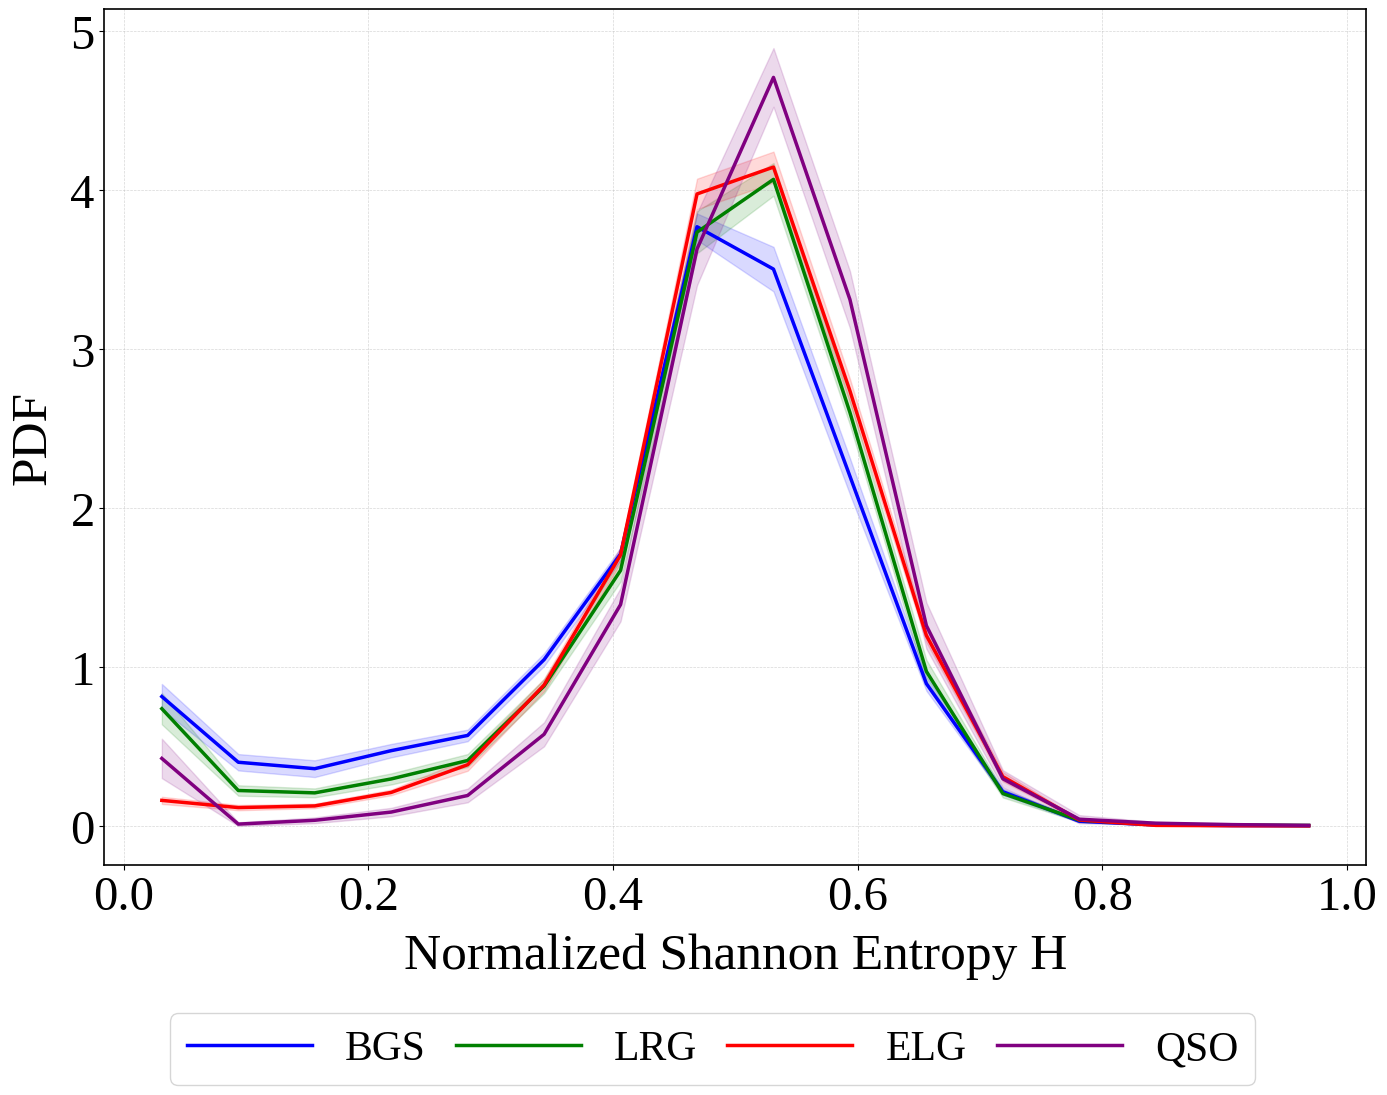

In [8]:
tracer_order = ['BGS_ANY', 'LRG', 'ELG', 'QSO']
tracer_label = {'BGS_ANY': 'BGS', 'LRG': 'LRG', 'ELG': 'ELG', 'QSO': 'QSO'}
tracer_color = {'BGS_ANY': 'blue', 'LRG': 'green', 'ELG': 'red', 'QSO': 'purple'}

entropy = {}
for p in pkl_files:
    with open(p, 'rb') as f:
        d = pickle.load(f)
    tr = d.get('TRACER')
    entropy[tr] = d

fig, ax = plt.subplots(figsize=(14, 10))
ax.grid(linewidth=0.5, alpha=0.5, linestyle='--')

for tr in tracer_order:
    if tr not in entropy:
        continue

    d = entropy[tr]
    x = np.asarray(d['BIN_CENTERS'], dtype=float)
    y = np.asarray(d['MEAN'], dtype=float)
    s = np.asarray(d['STD'], dtype=float)

    color = tracer_color.get(tr, 'black')
    label = tracer_label.get(tr, tr)

    ax.fill_between(x, y - s, y + s, color=color, alpha=0.15)
    ax.plot(x, y, color=color, linewidth=2.5, label=label)

ax.set_xlabel('Normalized Shannon Entropy H', fontsize=37,labelpad=10)
ax.set_ylabel('PDF', fontsize=37,labelpad=10)
ax.tick_params(axis='both', labelsize=35)
fig.subplots_adjust(bottom=0.22)
bb = ax.get_position()
fig.legend(
        *ax.get_legend_handles_labels(),
        loc='upper left',
        ncol=4,
        frameon=True,
        fontsize=30,
        mode='expand',
        bbox_to_anchor=(bb.x0, bb.y0 - 0.24, bb.width, 0.001),
        bbox_transform=fig.transFigure,
        borderaxespad=0.0,
        columnspacing=6,
        handlelength=3,
    )
plt.tight_layout()
plt.show()
